In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/yuvraj1160/ML-_Prac_1/refs/heads/main/adult.csv")

In [4]:
display(df.head(10))
display(df.tail(10))

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32551,43,Self-emp-not-inc,27242,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,50,United-States,<=50K
32552,32,Private,34066,10th,6,Married-civ-spouse,Handlers-cleaners,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
32553,43,Private,84661,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
32554,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
32555,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [5]:
df.info()
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
display(df.isnull().sum())

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [7]:
df.replace('?', np.nan, inplace=True)
df.replace(' ?', np.nan, inplace=True)

for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after handling:\n\n", df.isnull().sum())

Missing values after handling:

 age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


/tmp/ipykernel_871/1519857011.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [9]:
#convert category data into numeric data
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

display(df.head())

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,3,77053,11,9,6,9,1,4,0,0,4356,40,38,0
1,82,3,132870,11,9,6,3,1,4,0,0,4356,18,38,0
2,66,3,186061,15,10,6,9,4,2,0,0,4356,40,38,0
3,54,3,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,3,264663,15,10,5,9,3,4,0,0,3900,40,38,0


In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X = df.drop('income', axis=1)
y = df['income']

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Scaled Features Dataset:")
display(X_scaled.head())

Scaled Features Dataset:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,3.769612,-0.085296,-1.067997,0.181332,-0.420060,2.249480,0.720237,-0.277805,0.393668,-1.422331,-0.14592,10.593507,-0.035429,0.26137
1,3.183112,-0.085296,-0.539169,0.181332,-0.420060,2.249480,-0.790092,-0.277805,0.393668,-1.422331,-0.14592,10.593507,-1.817204,0.26137
2,2.010110,-0.085296,-0.035220,1.214869,-0.031360,2.249480,0.720237,1.589322,-1.962621,-1.422331,-0.14592,10.593507,-0.035429,0.26137
3,1.130359,-0.085296,-0.468215,-1.368974,-2.363558,-1.734058,-0.034928,1.589322,0.393668,-1.422331,-0.14592,9.461864,-0.035429,0.26137
4,0.177296,-0.085296,0.709482,1.214869,-0.031360,1.585557,0.720237,0.966947,0.393668,-1.422331,-0.14592,9.461864,-0.035429,0.26137


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.30, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print("Original Dataset Shape:", X_scaled.shape, y.shape,"\n")
print("Training Dataset (70%) Shape:", X_train.shape, y_train.shape,"\n")
print("Validation Dataset (15%) Shape:", X_val.shape, y_val.shape,"\n")
print("Testing Dataset (15%) Shape:", X_test.shape, y_test.shape,"\n")

Original Dataset Shape: (32561, 14) (32561,) 

Training Dataset (70%) Shape: (22792, 14) (22792,) 

Validation Dataset (15%) Shape: (4884, 14) (4884,) 

Testing Dataset (15%) Shape: (4885, 14) (4885,) 



Correlation Matrix Results ---
Top 5 features based on Correlation:
 education.num     0.337458
relationship      0.245866
age               0.234856
capital.gain      0.224087
hours.per.week    0.223868
Name: income, dtype: float64


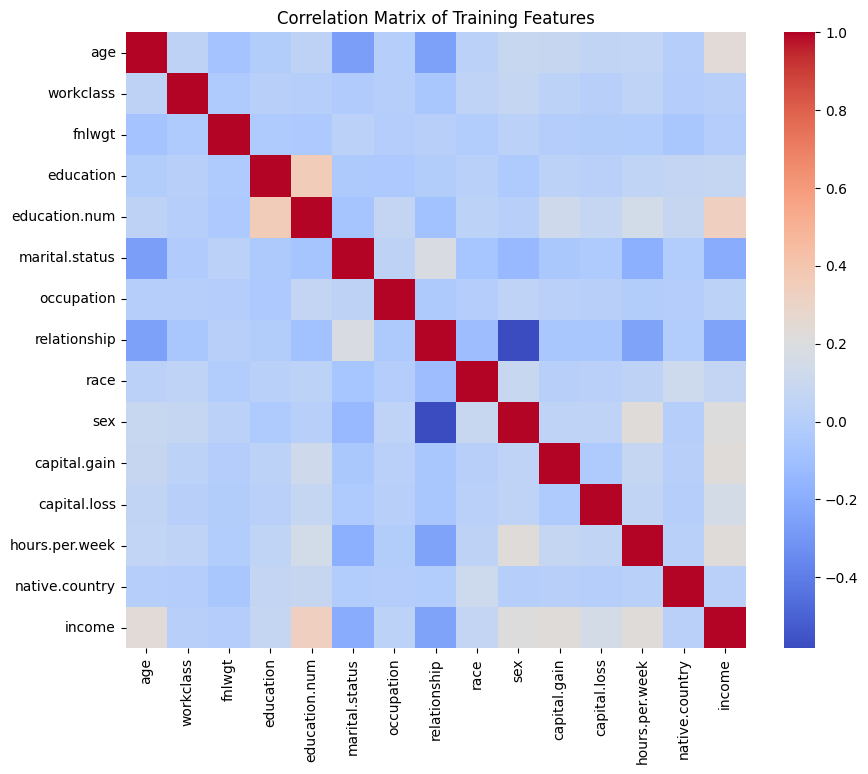


SelectKBest Results ---
Top 5 features based on SelectKBest:
            Feature        Score
4    education.num  2928.798065
7     relationship  1466.291625
0              age  1330.424093
10    capital.gain  1204.904916
12  hours.per.week  1202.430581


In [12]:
from sklearn.feature_selection import SelectKBest, f_classif

print("Correlation Matrix Results ---")
train_data = X_train.copy()
train_data['income'] = y_train.values
corr_matrix = train_data.corr()

corr_target = abs(corr_matrix['income']).sort_values(ascending=False)
print("Top 5 features based on Correlation:\n", corr_target[1:6])

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation Matrix of Training Features")
plt.show()


print("\nSelectKBest Results ---")

selector = SelectKBest(score_func=f_classif, k=5)
selector.fit(X_train, y_train)

feature_scores = pd.DataFrame({'Feature': X_train.columns, 'Score': selector.scores_})
feature_scores = feature_scores.sort_values(by='Score', ascending=False)

print("Top 5 features based on SelectKBest:\n", feature_scores.head(5))

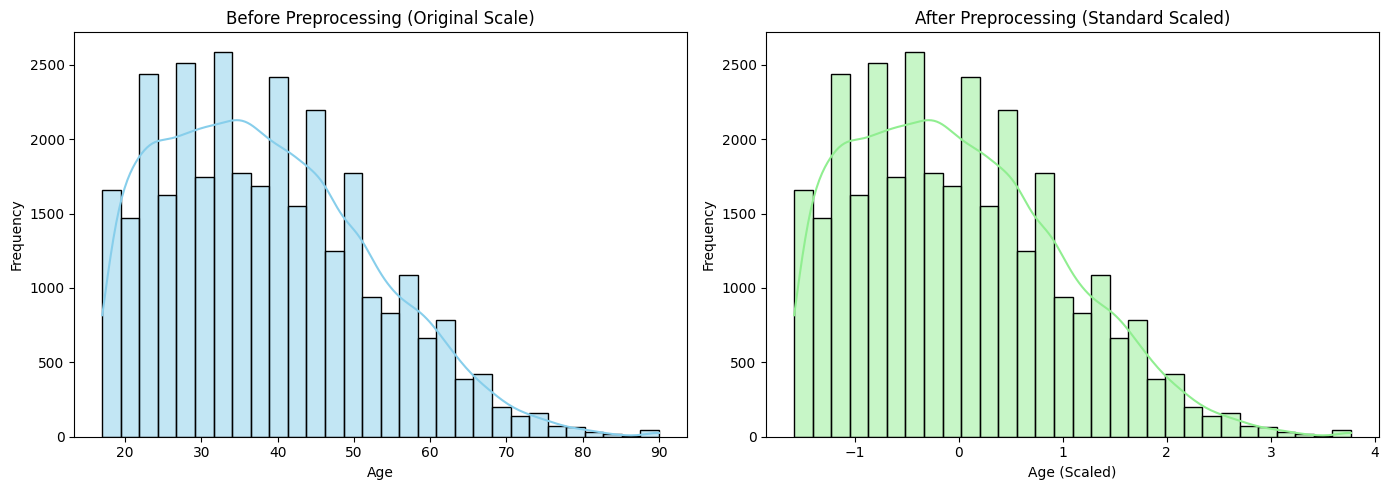

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before Preprocessing (Original Scale)
sns.histplot(df['age'], kde=True, ax=axes[0], color='skyblue', bins=30)
axes[0].set_title("Before Preprocessing (Original Scale)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

# After Preprocessing (Scaled )
sns.histplot(X_scaled['age'], kde=True, ax=axes[1], color='lightgreen', bins=30)
axes[1].set_title("After Preprocessing (Standard Scaled)")
axes[1].set_xlabel("Age (Scaled)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [14]:
df.to_csv("preprocessed_dataset.csv", index=False)


#Submitted By: Yuvraj Singh | Roll No: BETN1AI25123

###Conclusion:
In this lab evaluation, the Adult Income dataset was successfully cleaned and prepared for Machine Learning. Missing values ('?') were handled using the mode, and categorical features were encoded into numeric values via LabelEncoder. StandardScaler was then applied to normalize feature ranges, significantly improving overall data quality. Following this, the dataset was partitioned into Training (70%), Validation (15%), and Testing (15%) subsets for unbiased evaluation. Finally, Feature Selection techniques (Correlation Matrix and SelectKBest) identified key demographic attributes like age, education, and capital gains as the most important income predictors. These preprocessing steps successfully transformed the raw dataset into a standardized and optimized format ready for accurate model training.